# 1. Data Loading

In this section, we load the CICIDS2017 sample dataset used in the reproduction study.  
The goal is to inspect the dataset structure, feature names, feature types, missing values, duplicate rows, and label distribution before performing EDA and modeling.

In [71]:
# =========================
# 1. Imports and Settings
# =========================

import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [72]:
# =========================
# 2. Load Dataset
# =========================

from google.colab import files

uploaded = files.upload()

Saving CICIDS2017_sample.csv to CICIDS2017_sample (1).csv


In [73]:
# Automatically detect the uploaded CSV file
csv_files = [file_name for file_name in uploaded.keys() if file_name.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was uploaded. Please upload CICIDS2017_sample.csv.")

DATA_PATH = csv_files[0]
print(f"Loaded file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Loaded file: CICIDS2017_sample (1).csv
Dataset loaded successfully.
Shape: (56661, 78)


In [74]:
# =========================
# 3. Basic Dataset Inspection
# =========================

def inspect_dataset(data: pd.DataFrame) -> None:
    """Print basic information about the dataset."""
    print("Dataset shape:")
    print(f"Rows: {data.shape[0]:,}")
    print(f"Columns: {data.shape[1]:,}")

    print("\nFirst 5 rows:")
    display(data.head())

    print("\nColumn names:")
    display(pd.DataFrame({"column_name": data.columns}))

    print("\nData types:")
    display(data.dtypes.value_counts().to_frame("count"))

    print("\nDetailed info:")
    data.info()


inspect_dataset(df)

Dataset shape:
Rows: 56,661
Columns: 78

First 5 rows:


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,4,2,0,37,0,31,6,18.500000,17.677670,0,0,0.000000,0.000000,9.250000e+06,500000.000000,4.000000,0.000000,4,4,4,4.000000,0.000000,4,4,0,0.000000,0.000000,0,0,1,0,0,0,40,0,500000.000000,0.000000,6,31,22.666667,14.433757,2.083333e+02,0,1,0,0,1,0,0,0,0,34.000000,18.500000,0.000000,40,0,0,0,0,0,0,2,37,0,0,60,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,142377,46,62,1325,105855,570,0,28.804348,111.407285,4344,0,1707.338710,846.172655,7.527901e+05,758.549485,1330.626168,5048.982697,23198,0,142377,3163.933333,7552.916858,23792,0,119204,1954.163934,6058.842404,23865,4,0,0,0,0,1168,1992,323.085892,435.463593,0,4344,983.302752,1052.392050,1.107529e+06,0,0,0,1,0,0,0,0,1,992.407407,28.804348,1707.338710,1168,0,0,0,0,0,0,46,1325,62,105855,29200,61,30,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118873,23,28,1169,45025,570,0,50.826087,156.137367,2896,0,1608.035714,902.027366,3.885996e+05,429.029300,2377.460000,6838.420713,23435,3,118873,5403.318182,9768.511157,24311,49,95541,3538.555556,8193.060024,24168,3,0,0,0,0,744,904,193.483802,235.545498,0,2896,888.346154,1028.323762,1.057450e+06,0,0,0,1,0,0,0,0,1,905.764706,50.826087,1608.035714,744,0,0,0,0,0,0,23,1169,28,45025,29200,61,4,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,143577,43,55,1301,107289,570,0,30.255814,115.178969,4344,0,1950.709091,928.230389,7.563189e+05,682.560577,1480.175258,5316.455522,23220,2,143530,3417.380952,7846.824009,23823,2,120357,2228.833333,6441.592862,23889,2,0,0,0,0,1120,1768,299.490865,383.069712,0,4344,1096.868687,1183.665309,1.401064e+06,0,0,0,1,0,0,0,0,1,1108.061224,30.255814,1950.709091,1120,0,0,0,0,0,0,43,1301,55,107289,29200,61,26,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,143745,49,59,1331,110185,570,0,27.163265,108.067176,4344,0,1867.542373,928.861935,7.757905e+05,751.330481,1343.411215,5112.820617,24181,2,143726,2994.291667,7449.818687,24248,2,120164,2071.793103,6233.858327,24616,2,0,0,0,0,1252,1896,340.881422,410.449059,0,4344,1023.082569,1147.958350,1.317808e+06,0,0,0,1,0,0,0,0,1,1032.555556,27.163265,1867.542373,1252,0,0,0,0,0,0,49,1331,59,110185,29200,61,31,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Column names:


,column_name
0,Flow Duration
1,Total Fwd Packets
2,Total Backward Packets
3,Total Length of Fwd Packets
4,Total Length of Bwd Packets
5,Fwd Packet Length Max
6,Fwd Packet Length Min
7,Fwd Packet Length Mean
8,Fwd Packet Length Std
9,Bwd Packet Length Max



Data types:


,count
int64,53
float64,24
object,1



Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56661 entries, 0 to 56660
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow Duration                56661 non-null  int64  
 1   Total Fwd Packets            56661 non-null  int64  
 2   Total Backward Packets       56661 non-null  int64  
 3   Total Length of Fwd Packets  56661 non-null  int64  
 4   Total Length of Bwd Packets  56661 non-null  int64  
 5   Fwd Packet Length Max        56661 non-null  int64  
 6   Fwd Packet Length Min        56661 non-null  int64  
 7   Fwd Packet Length Mean       56661 non-null  float64
 8   Fwd Packet Length Std        56661 non-null  float64
 9   Bwd Packet Length Max        56661 non-null  int64  
 10  Bwd Packet Length Min        56661 non-null  int64  
 11  Bwd Packet Length Mean       56661 non-null  float64
 12  Bwd Packet Length Std        56661 non-null  float64
 13  

In [75]:
# =========================
# 4. Clean Column Names
# =========================

def clean_column_names(data: pd.DataFrame) -> pd.DataFrame:
    """
    Clean column names by removing leading/trailing spaces.
    CICIDS2017 commonly contains columns with leading spaces.
    """
    cleaned_data = data.copy()
    cleaned_data.columns = cleaned_data.columns.str.strip()
    return cleaned_data


df = clean_column_names(df)

print("Column names cleaned.")
print(df.columns.tolist()[:10])

Column names cleaned.
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max']


In [76]:
# =========================
# 5. Identify Target Column
# =========================

def find_target_column(data: pd.DataFrame) -> str:
    """Find the target label column using common CICIDS2017 naming conventions."""
    possible_targets = ["Label", "label", "Class", "class", "Attack", "attack"]

    for column in possible_targets:
        if column in data.columns:
            return column

    raise ValueError("Could not find target column. Please check the dataset columns.")


target_column = find_target_column(df)
print(f"Target column: {target_column}")

print("\nClass distribution:")
display(df[target_column].value_counts().to_frame("count"))

Target column: Label

Class distribution:


,count
Label,
BENIGN,22731
DoS,19035
PortScan,7946
BruteForce,2767
WebAttack,2180
Bot,1966
Infiltration,36


In [77]:
# =========================
# 6. Feature Type Summary
# =========================

def summarize_feature_types(data: pd.DataFrame, target: str) -> pd.DataFrame:
    """Summarize numeric and non-numeric feature counts."""
    feature_data = data.drop(columns=[target])

    numeric_features = feature_data.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = feature_data.select_dtypes(exclude=[np.number]).columns.tolist()

    summary = pd.DataFrame({
        "feature_type": ["numeric", "categorical_or_object"],
        "count": [len(numeric_features), len(categorical_features)]
    })

    return summary


feature_type_summary = summarize_feature_types(df, target_column)
display(feature_type_summary)

,feature_type,count
0,numeric,77
1,categorical_or_object,0


In [78]:
# =========================
# 7. Data Quality Checks
# =========================

def data_quality_report(data: pd.DataFrame) -> pd.DataFrame:
    """Create a compact data quality report for each column."""
    report = pd.DataFrame({
        "dtype": data.dtypes.astype(str),
        "missing_count": data.isna().sum(),
        "missing_percent": data.isna().mean() * 100,
        "unique_values": data.nunique(dropna=False)
    })

    return report.sort_values("missing_percent", ascending=False)


quality_report = data_quality_report(df)

print("Top columns by missing percentage:")
display(quality_report.head(15))

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count:,}")

numeric_columns = df.select_dtypes(include=[np.number]).columns
infinite_count = np.isinf(df[numeric_columns]).sum().sum()

print(f"Infinite numeric values: {infinite_count:,}")

Top columns by missing percentage:


,dtype,missing_count,missing_percent,unique_values
Flow Bytes/s,float64,54,0.095304,35180
Flow Duration,int64,0,0.000000,33784
Total Backward Packets,int64,0,0.000000,219
Total Length of Fwd Packets,int64,0,0.000000,2511
Total Length of Bwd Packets,int64,0,0.000000,3519
Total Fwd Packets,int64,0,0.000000,191
Fwd Packet Length Max,int64,0,0.000000,1320
Fwd Packet Length Min,int64,0,0.000000,128
Fwd Packet Length Std,float64,0,0.000000,7427
Fwd Packet Length Mean,float64,0,0.000000,4755



Duplicate rows: 12,598
Infinite numeric values: 108


In [79]:
# =========================
# 8. Handle Infinite Values
# =========================

def replace_infinite_values(data: pd.DataFrame) -> pd.DataFrame:
    """Replace positive and negative infinity with NaN."""
    cleaned_data = data.copy()
    numeric_columns = cleaned_data.select_dtypes(include=[np.number]).columns
    cleaned_data[numeric_columns] = cleaned_data[numeric_columns].replace([np.inf, -np.inf], np.nan)
    return cleaned_data


df = replace_infinite_values(df)

print("Infinite values were replaced with NaN if any existed.")
print(f"Total missing values after replacement: {df.isna().sum().sum():,}")

Infinite values were replaced with NaN if any existed.
Total missing values after replacement: 162


In [80]:
# =========================
# 9. Index and Single-Value Column Checks
# =========================

def find_single_value_columns(data: pd.DataFrame) -> list:
    """Return columns with only one unique value."""
    return [column for column in data.columns if data[column].nunique(dropna=False) == 1]


single_value_columns = find_single_value_columns(df)

print(f"Index type: {type(df.index)}")
print(f"Index is unique: {df.index.is_unique}")
print(f"Number of single-value columns: {len(single_value_columns)}")

if single_value_columns:
    print("Single-value columns:")
    print(single_value_columns)

Index type: <class 'pandas.core.indexes.range.RangeIndex'>
Index is unique: True
Number of single-value columns: 8
Single-value columns:
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [81]:
# =========================
# 10. Temporal Feature Check
# =========================

def find_temporal_columns(data: pd.DataFrame) -> list:
    """Find columns that may represent temporal information."""
    temporal_keywords = ["time", "timestamp", "date", "duration"]
    return [
        column for column in data.columns
        if any(keyword in column.lower() for keyword in temporal_keywords)
    ]


temporal_columns = find_temporal_columns(df)

print("Potential temporal columns:")
print(temporal_columns)

Potential temporal columns:
['Flow Duration']


# 2. EDA

In [82]:
# =========================
# Identify Constant Features
# =========================

constant_features = [
    col for col in df.columns
    if col != target_column and df[col].nunique(dropna=False) == 1
]

print(f"Constant features: {len(constant_features)}")
print(constant_features)

eda_features = [
    col for col in df.columns
    if col != target_column and col not in constant_features
]

print(f"\nFeatures used in EDA: {len(eda_features)}")

Constant features: 8
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Features used in EDA: 69


In [83]:
# =========================
# Distribution Statistics
# =========================

distribution_summary = pd.DataFrame({
    "mean": df[eda_features].mean(),
    "median": df[eda_features].median(),
    "std": df[eda_features].std(),
    "skewness": df[eda_features].skew(),
    "kurtosis": df[eda_features].kurtosis()
})

display(
    distribution_summary
    .sort_values("skewness", ascending=False)
    .head(69)
)

,mean,median,std,skewness,kurtosis
Fwd URG Flags,1.764882e-05,0.000000,4.201050e-03,238.035712,56661.000000
CWE Flag Count,1.764882e-05,0.000000,4.201050e-03,238.035712,56661.000000
Total Length of Bwd Packets,5.282417e+03,79.000000,1.092694e+05,152.733293,27834.220040
Subflow Bwd Bytes,5.281813e+03,79.000000,1.091506e+05,152.589748,27786.957685
Total Length of Fwd Packets,7.325051e+02,31.000000,2.135208e+04,97.114110,10655.746642
Subflow Fwd Bytes,7.325051e+02,31.000000,2.135208e+04,97.114110,10655.746642
Subflow Bwd Packets,5.441168e+00,2.000000,6.651316e+01,89.948683,10602.804218
Total Backward Packets,5.441168e+00,2.000000,6.651316e+01,89.948683,10602.804218
Bwd Header Length,1.457560e+02,40.000000,1.356452e+03,85.086301,9805.568448
RST Flag Count,1.411906e-04,0.000000,1.188163e-02,84.142736,7078.249846


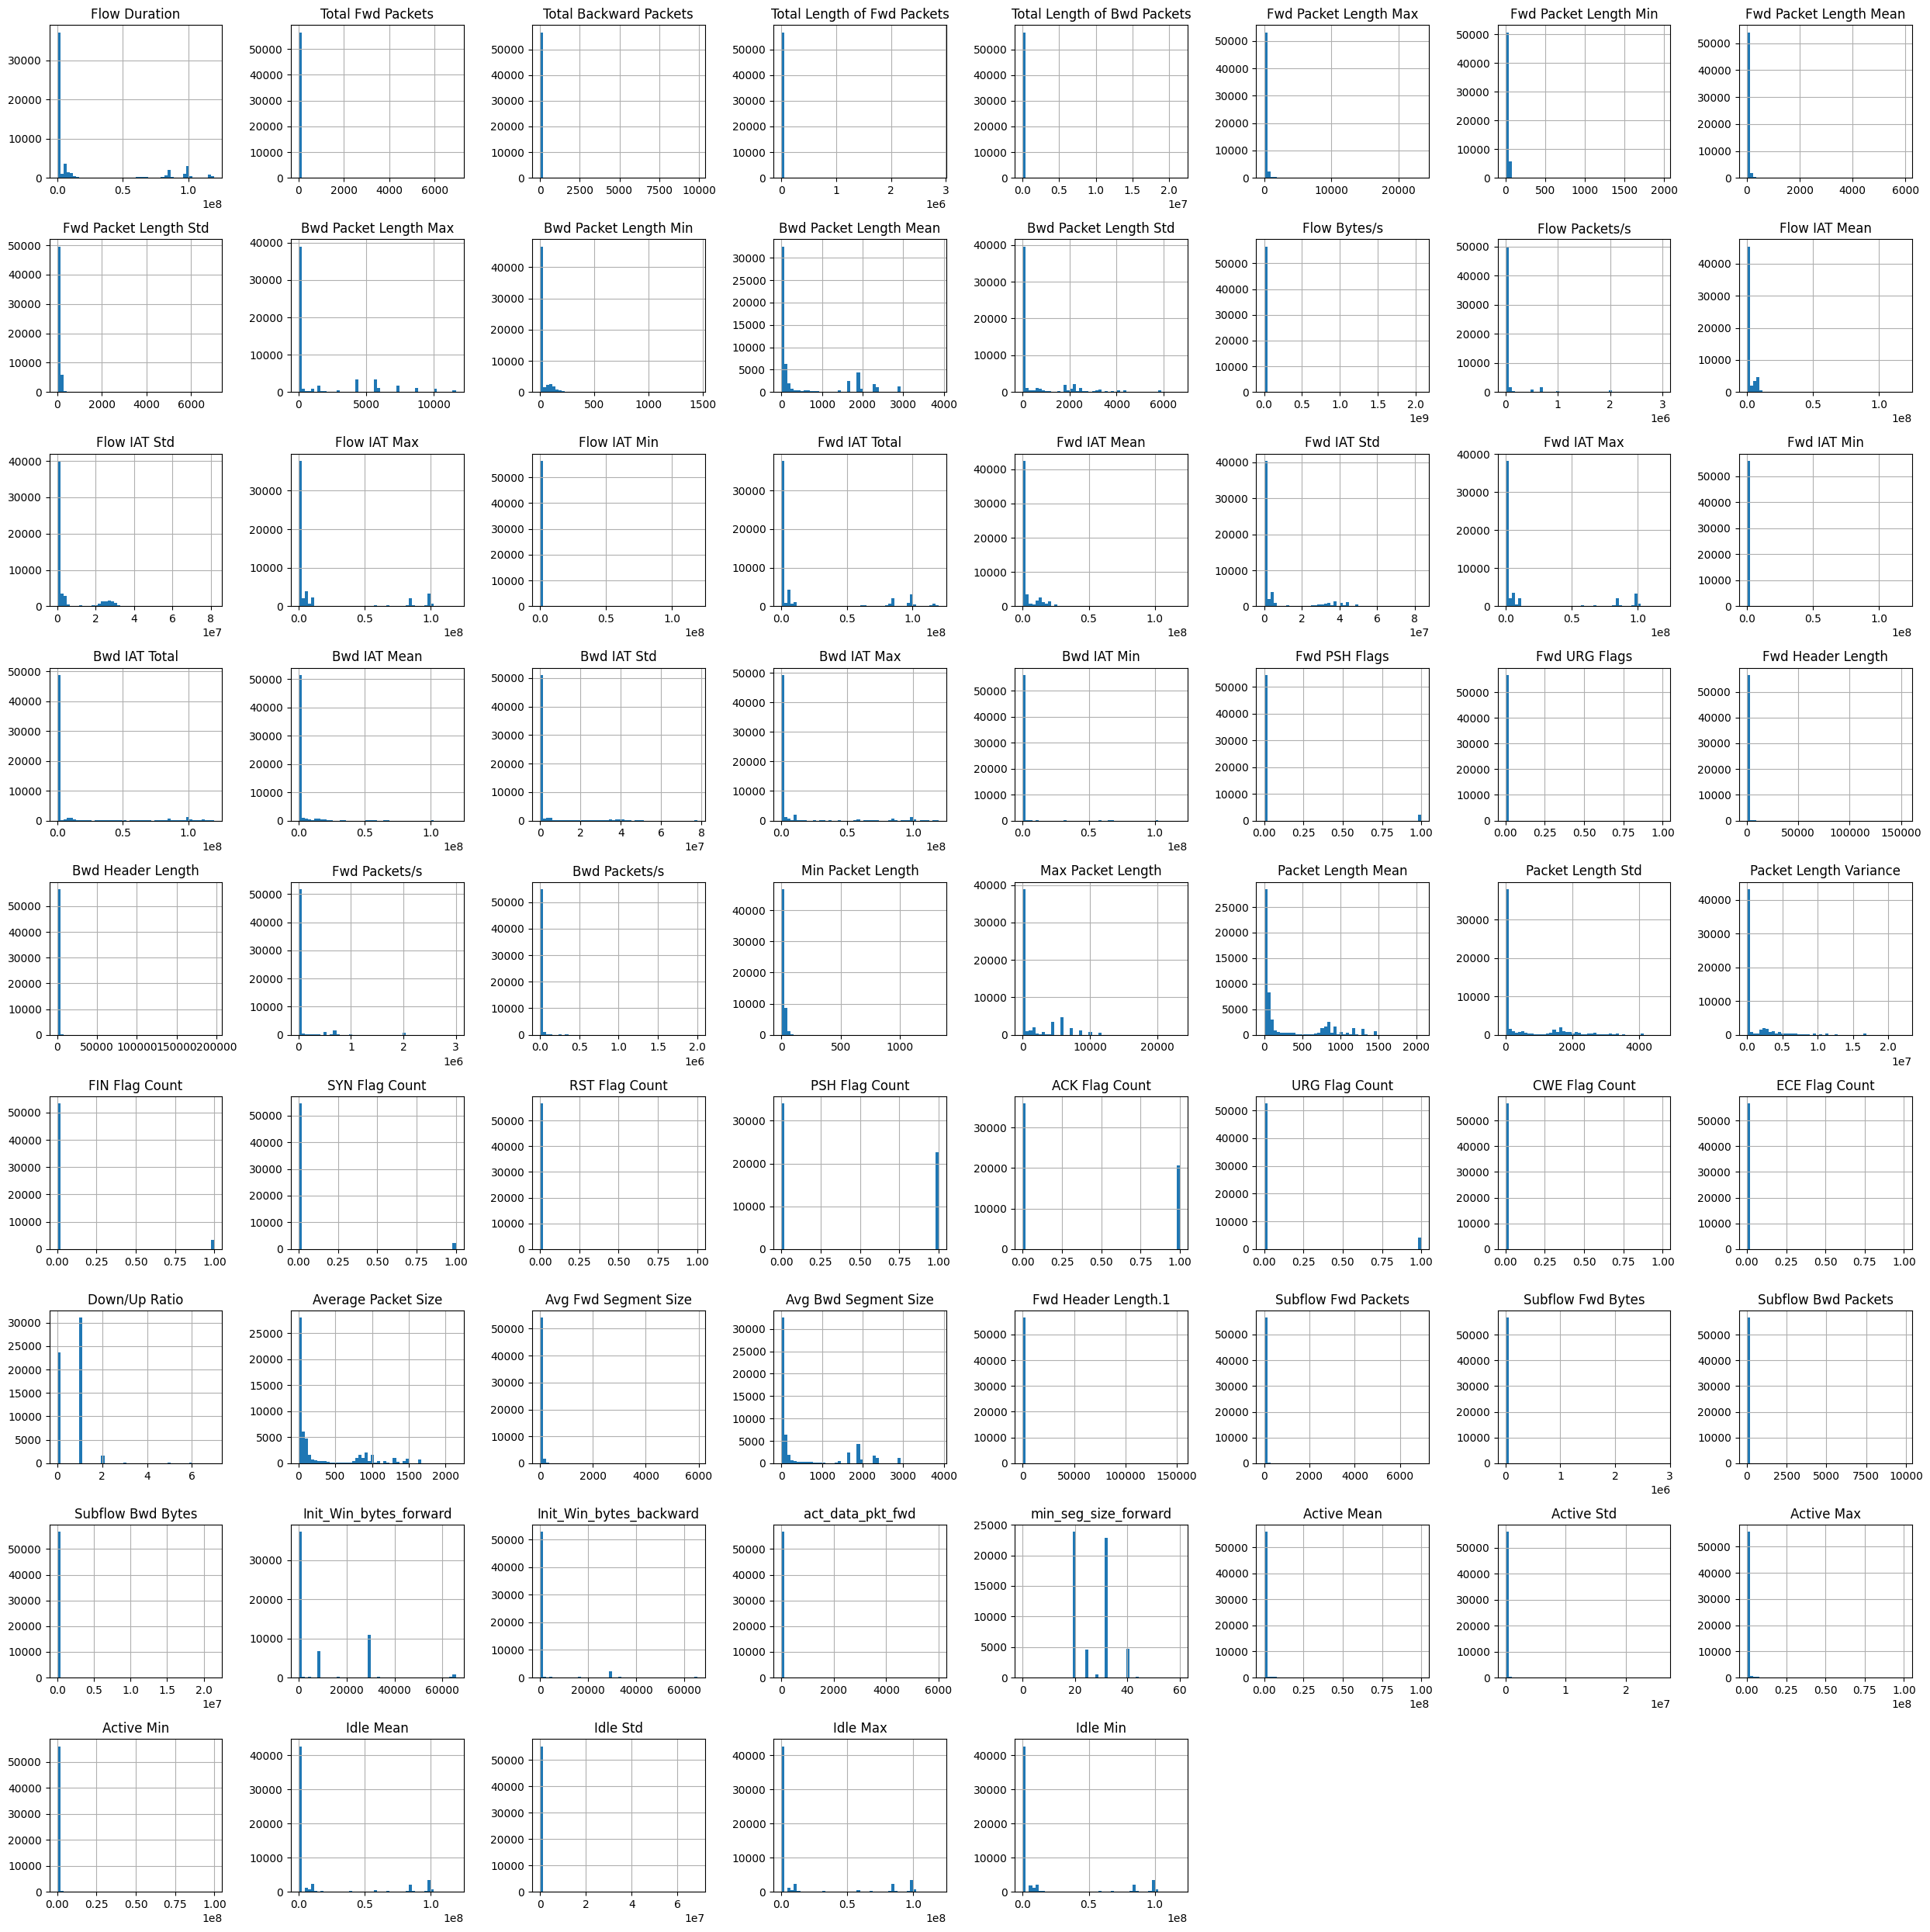

In [84]:
# =========================
# Histograms
# =========================

df[eda_features].hist(
    figsize=(25,25),
    bins=50
)

plt.tight_layout()
plt.show()

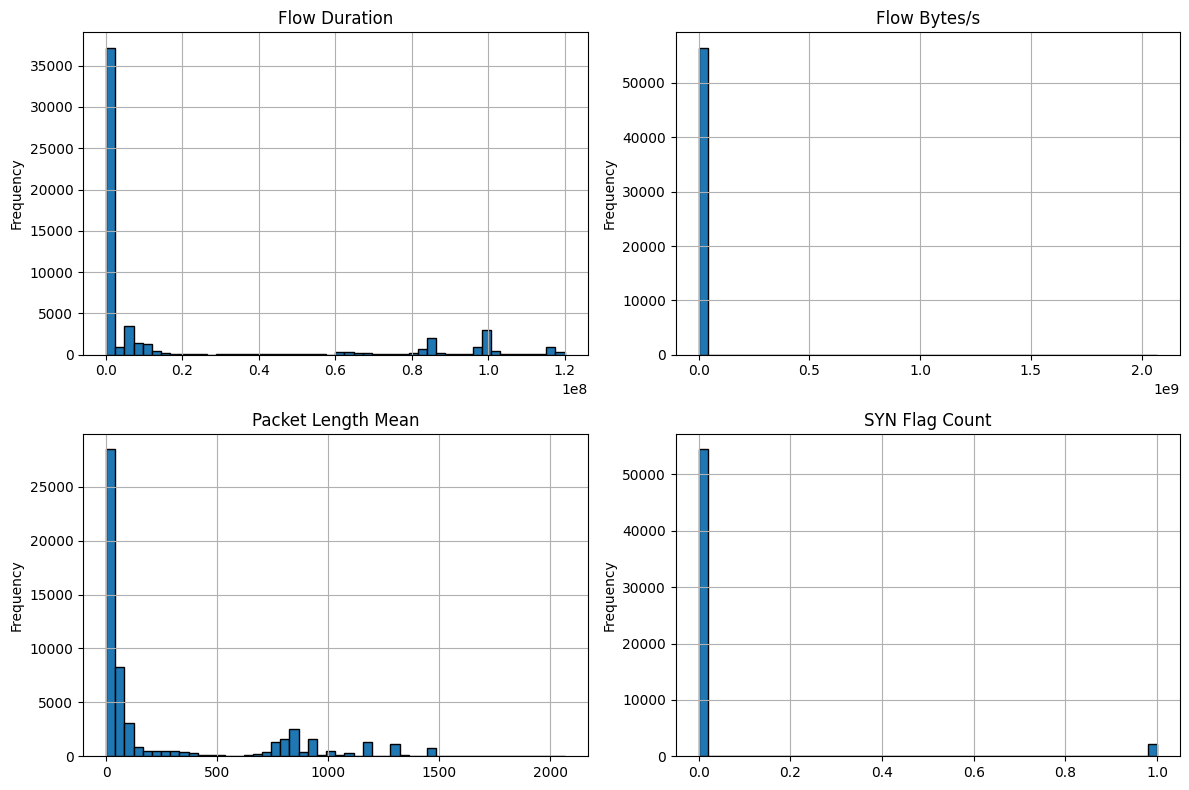

In [85]:
# =========================
# Representative Feature Distributions
# =========================

representative_features = [
    "Flow Duration",
    "Flow Bytes/s",
    "Packet Length Mean",
    "SYN Flag Count"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, representative_features):
    df[feature].hist(
        bins=50,
        ax=ax,
        edgecolor="black"
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Columns with missing values: 2


,missing_count
Flow Bytes/s,81
Flow Packets/s,81


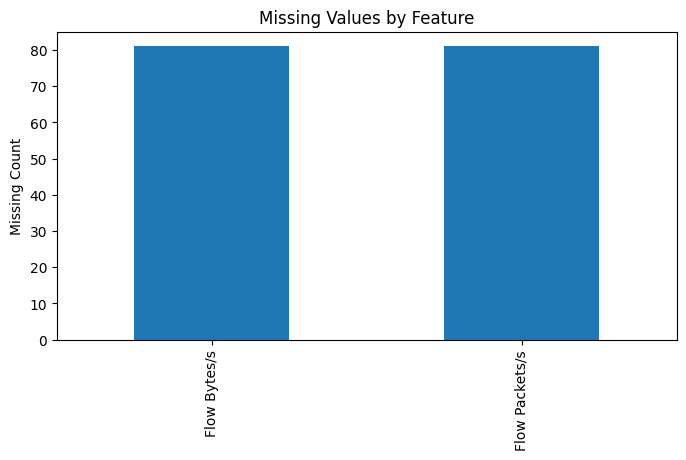

In [86]:
# =========================
# Missing Values Analysis
# =========================

missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]

print(f"Columns with missing values: {len(missing_counts)}")

display(
    missing_counts.sort_values(ascending=False)
    .to_frame("missing_count")
)

if len(missing_counts) > 0:
    plt.figure(figsize=(8,4))
    missing_counts.sort_values(ascending=False).plot(kind="bar")
    plt.title("Missing Values by Feature")
    plt.ylabel("Missing Count")
    plt.show()

In [87]:
# =========================
# IQR Outlier Analysis
# =========================

outlier_summary = []

for feature in eda_features:

    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (df[feature] < lower) |
        (df[feature] > upper)
    ).sum()

    outlier_summary.append({
        "feature": feature,
        "outlier_count": outliers,
        "outlier_percent":
            100 * outliers / len(df)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(
    outlier_summary
    .sort_values("outlier_percent", ascending=False)
    .head(69)
)

,feature,outlier_count,outlier_percent
67,Idle Max,14039,24.777184
68,Idle Min,14039,24.777184
65,Idle Mean,14039,24.777184
61,Active Mean,13660,24.108293
64,Active Min,13660,24.108293
63,Active Max,13660,24.108293
39,Packet Length Variance,12897,22.761688
36,Max Packet Length,12504,22.068089
51,Avg Bwd Segment Size,12463,21.995729
11,Bwd Packet Length Mean,12463,21.995729


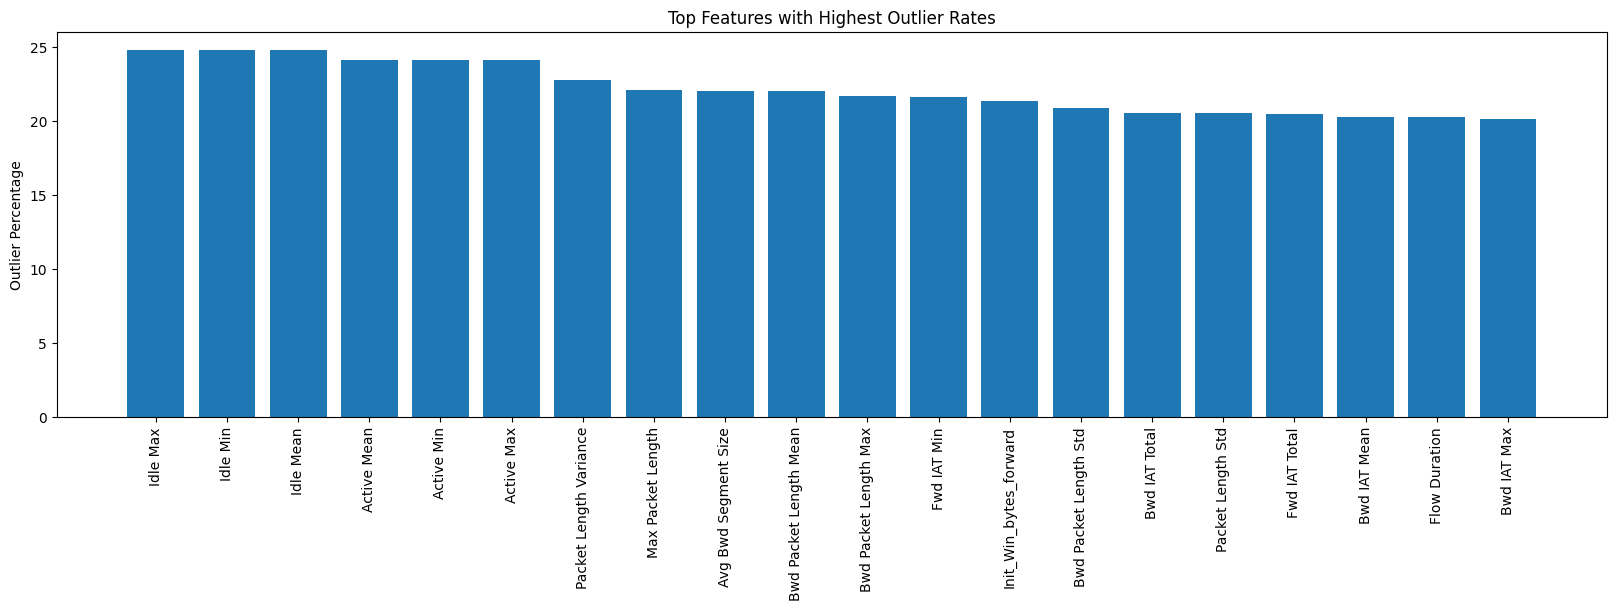

In [88]:
# =========================
# Top Outlier Features
# =========================

top_outlier_features = (
    outlier_summary
    .sort_values("outlier_percent", ascending=False)
    .head(20)
)

plt.figure(figsize=(20,5))

plt.bar(
    top_outlier_features["feature"],
    top_outlier_features["outlier_percent"]
)

plt.xticks(rotation=90)
plt.ylabel("Outlier Percentage")
plt.title("Top Features with Highest Outlier Rates")

plt.show()

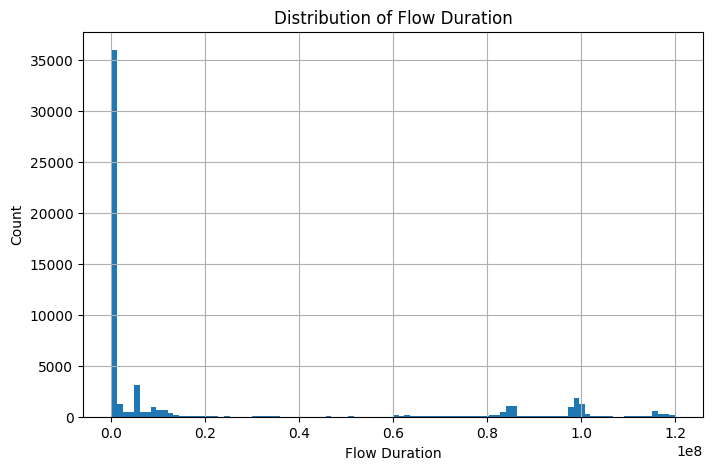

count    5.666100e+04
mean     1.940740e+07
std      3.672377e+07
min      0.000000e+00
25%      7.200000e+01
50%      5.889700e+04
75%      8.813192e+06
max      1.200000e+08
Name: Flow Duration, dtype: float64


In [89]:
# =========================
# Temporal Analysis
# =========================

plt.figure(figsize=(8,5))

df["Flow Duration"].hist(bins=100)

plt.title("Distribution of Flow Duration")
plt.xlabel("Flow Duration")
plt.ylabel("Count")
plt.show()

print(df["Flow Duration"].describe())

In [90]:
# =========================
# Pearson and Spearman Correlations
# =========================

pearson_corr = df[eda_features].corr(method="pearson")
spearman_corr = df[eda_features].corr(method="spearman")

print("Pearson correlation matrix shape:", pearson_corr.shape)
print("Spearman correlation matrix shape:", spearman_corr.shape)

Pearson correlation matrix shape: (69, 69)
Spearman correlation matrix shape: (69, 69)


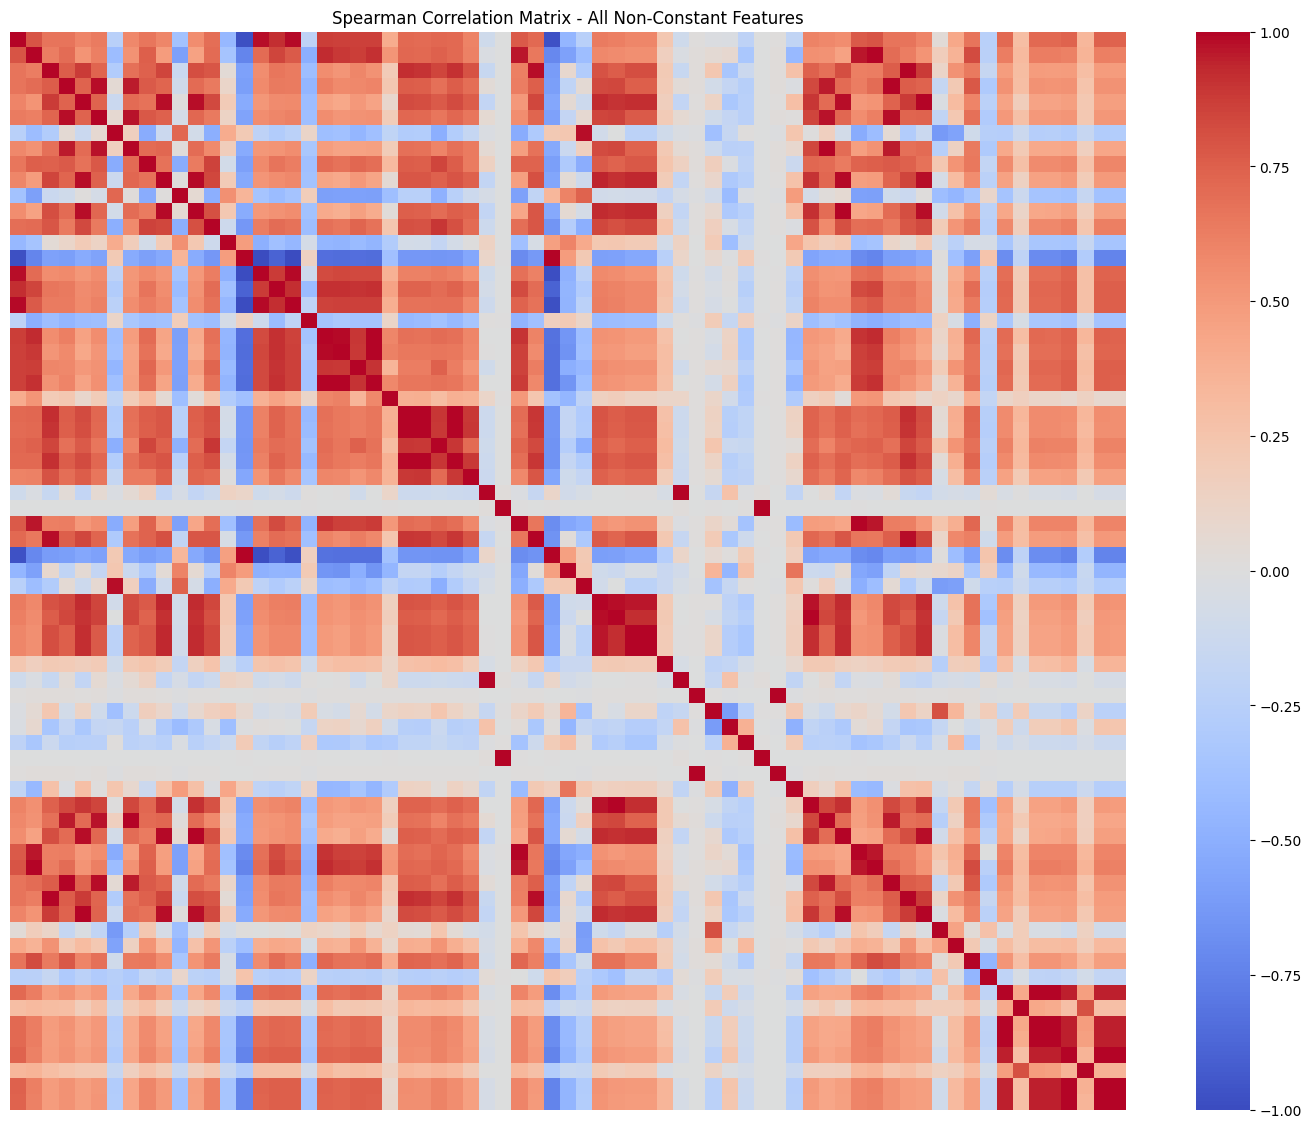

In [91]:
# =========================
# Full Spearman Correlation Heatmap
# =========================

import seaborn as sns

plt.figure(figsize=(18, 14))

sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False
)

plt.title("Spearman Correlation Matrix - All Non-Constant Features")
plt.show()

In [92]:
# =========================
# Highly Correlated Feature Pairs
# =========================

def get_high_correlation_pairs(
    correlation_matrix: pd.DataFrame,
    threshold: float = 0.90
) -> pd.DataFrame:
    """
    Return feature pairs with absolute correlation above a given threshold.
    Only the upper triangle of the correlation matrix is used to avoid duplicates.
    """
    pairs = []

    columns = correlation_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            correlation_value = correlation_matrix.iloc[i, j]

            if abs(correlation_value) >= threshold:
                pairs.append({
                    "Feature_A": columns[i],
                    "Feature_B": columns[j],
                    "Spearman_Correlation": correlation_value,
                    "Absolute_Correlation": abs(correlation_value)
                })

    return (
        pd.DataFrame(pairs)
        .sort_values("Absolute_Correlation", ascending=False)
        .reset_index(drop=True)
    )


high_corr_pairs = get_high_correlation_pairs(
    spearman_corr,
    threshold=0.90
)

print(f"Number of feature pairs with |Spearman correlation| >= 0.90: {len(high_corr_pairs)}")

display(high_corr_pairs.head(30))

Number of feature pairs with |Spearman correlation| >= 0.90: 114


,Feature_A,Feature_B,Spearman_Correlation,Absolute_Correlation
0,Total Backward Packets,Subflow Bwd Packets,1.000000,1.000000
1,Total Fwd Packets,Subflow Fwd Packets,1.000000,1.000000
2,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000,1.000000
3,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000,1.000000
4,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000,1.000000
5,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000,1.000000
6,RST Flag Count,ECE Flag Count,1.000000,1.000000
7,Fwd URG Flags,CWE Flag Count,1.000000,1.000000
8,Fwd PSH Flags,SYN Flag Count,1.000000,1.000000
9,Fwd Header Length,Fwd Header Length.1,1.000000,1.000000


In [93]:
# =========================
# Features Involved in High Correlations
# =========================

high_corr_features = sorted(
    set(high_corr_pairs["Feature_A"]).union(set(high_corr_pairs["Feature_B"]))
)

print(f"Number of features involved in |correlation| >= 0.90: {len(high_corr_features)}")


Number of features involved in |correlation| >= 0.90: 49


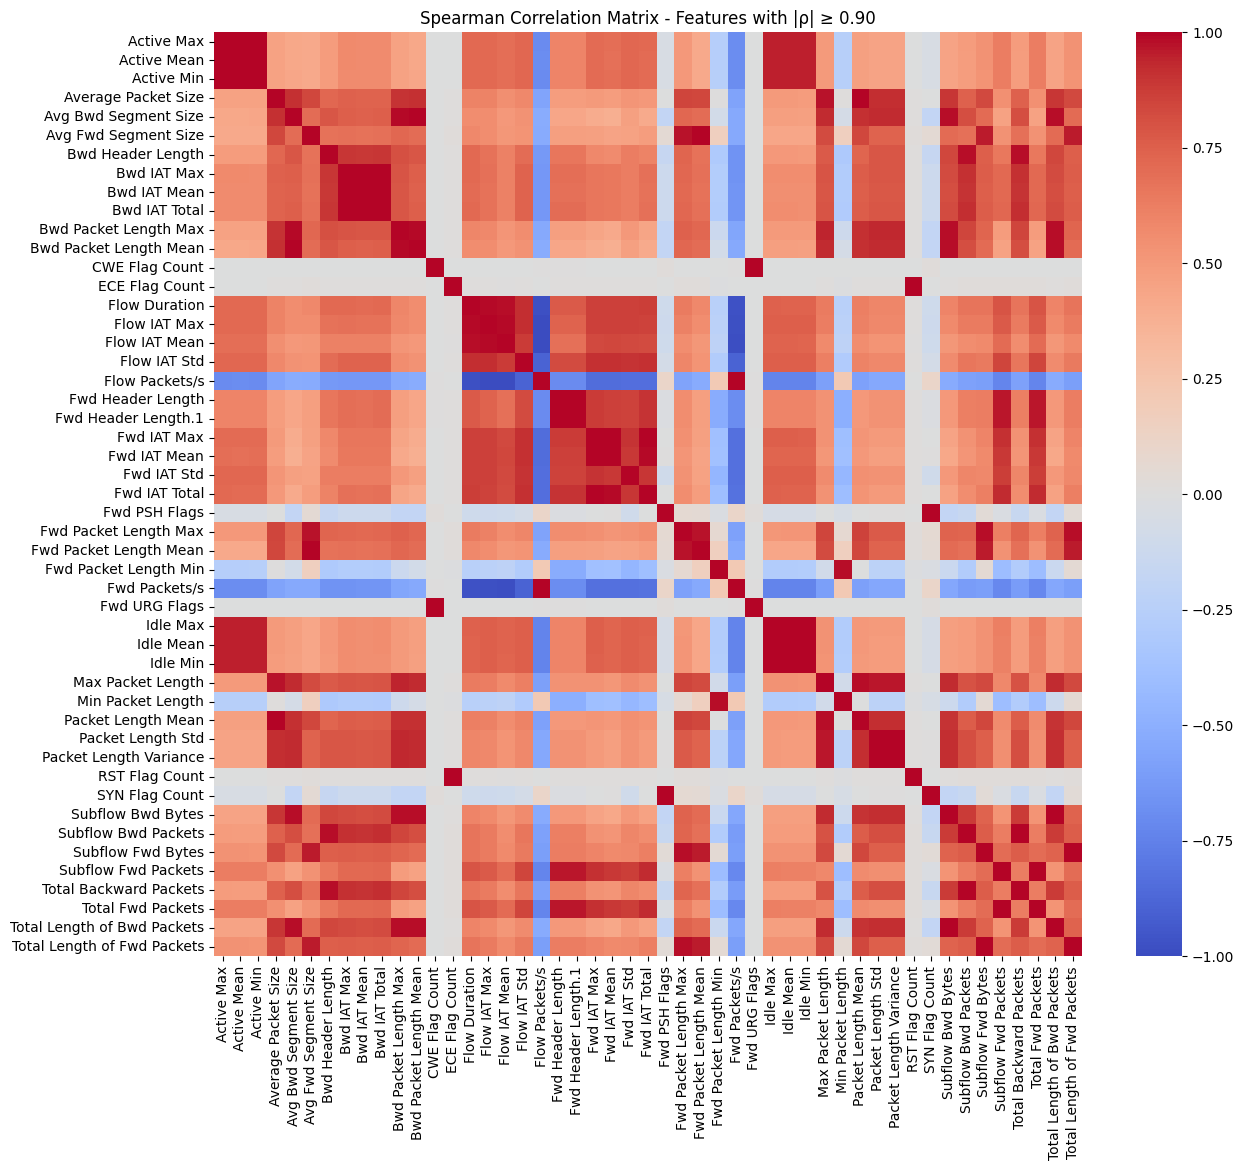

In [94]:
# =========================
# Reduced Heatmap for Highly Correlated Features
# =========================

if len(high_corr_features) > 1:
    reduced_spearman_corr = spearman_corr.loc[
        high_corr_features,
        high_corr_features
    ]

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        reduced_spearman_corr,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1
    )

    plt.title("Spearman Correlation Matrix - Features with |ρ| ≥ 0.90")
    plt.show()
else:
    print("Not enough highly correlated features to generate a reduced heatmap.")

Top features selected for report heatmap:
['Bwd Packet Length Mean', 'Packet Length Mean', 'Packet Length Std', 'Avg Bwd Segment Size', 'Bwd Packet Length Max', 'Packet Length Variance', 'Max Packet Length', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Average Packet Size']


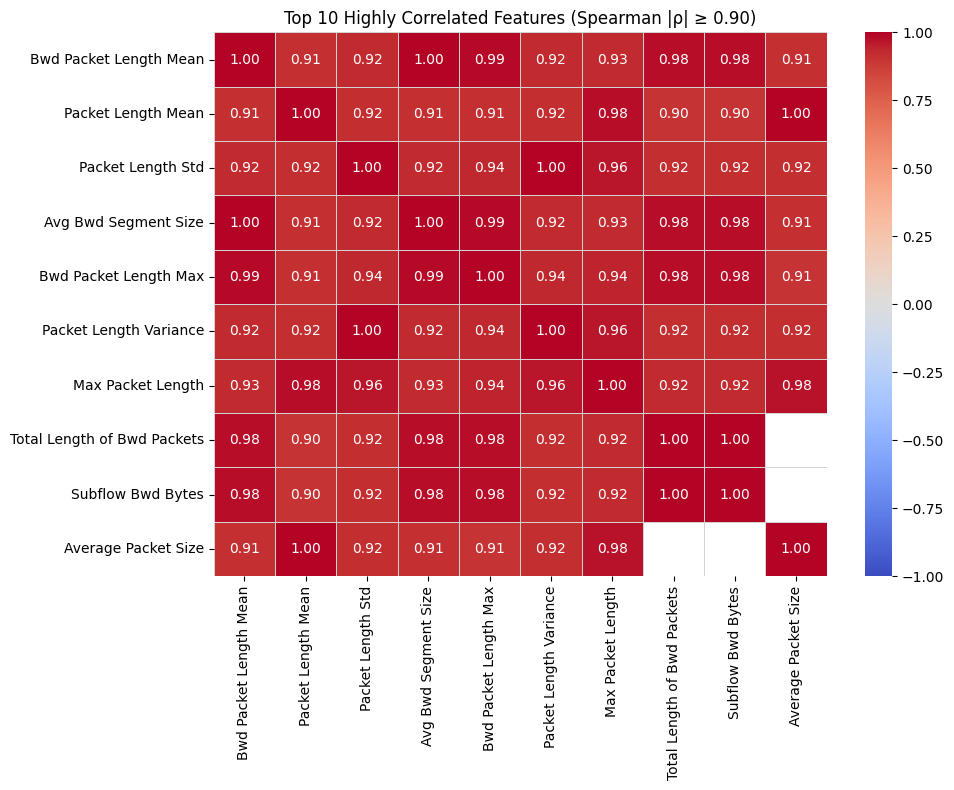

In [95]:
# =========================
# Clear Report Heatmap: Top 20 Highly Correlated Features
# =========================

HIGH_CORR_THRESHOLD = 0.90
TOP_N_FEATURES = 10

# Count how often each feature appears in highly correlated pairs
feature_counts = pd.concat([
    high_corr_pairs["Feature_A"],
    high_corr_pairs["Feature_B"]
]).value_counts()

top_corr_features = feature_counts.head(TOP_N_FEATURES).index.tolist()

print("Top features selected for report heatmap:")
print(top_corr_features)

# Create correlation matrix for selected features
report_corr_matrix = spearman_corr.loc[
    top_corr_features,
    top_corr_features
]

# Keep only correlations above threshold
masked_report_corr_matrix = report_corr_matrix.where(
    report_corr_matrix.abs() >= HIGH_CORR_THRESHOLD
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    masked_report_corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    mask=masked_report_corr_matrix.isna(),
    linewidths=0.5,
    linecolor="lightgray",
    annot=True,
    fmt=".2f"
)

plt.title("Top 10 Highly Correlated Features (Spearman |ρ| ≥ 0.90)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

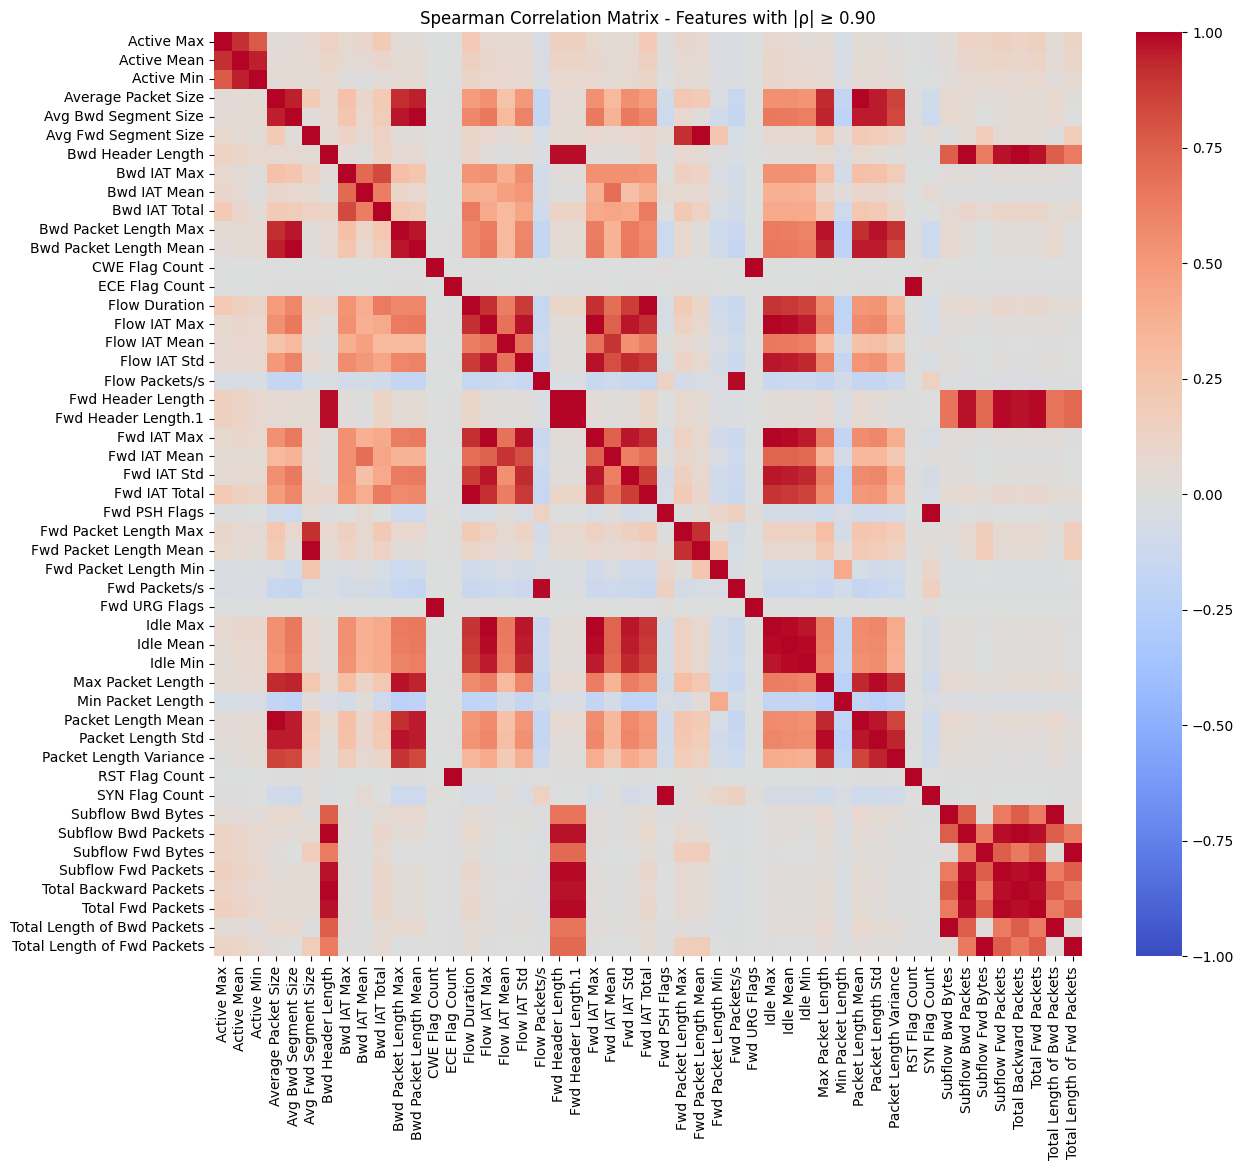

In [96]:
# =========================
# Full Pearson Correlation Heatmap
# =========================


if len(high_corr_features) > 1:
    reduced_pearson_corr = pearson_corr.loc[
        high_corr_features,
        high_corr_features
    ]

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        reduced_pearson_corr,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1
    )

    plt.title("Spearman Correlation Matrix - Features with |ρ| ≥ 0.90")
    plt.show()
else:
    print("Not enough highly correlated features to generate a reduced heatmap.")

In [97]:
# =========================
# Pearson vs Spearman Correlation Strength Summary
# =========================

pearson_correlation_strength_summary = summarize_correlation_strengths(pearson_corr)
spearman_correlation_strength_summary = summarize_correlation_strengths(spearman_corr)

correlation_method_comparison = (
    spearman_correlation_strength_summary
    .rename(columns={
        "pair_count": "spearman_pair_count",
        "percentage_of_pairs": "spearman_percentage_of_pairs"
    })
    .merge(
        pearson_correlation_strength_summary.rename(columns={
            "pair_count": "pearson_pair_count",
            "percentage_of_pairs": "pearson_percentage_of_pairs"
        }),
        on="threshold"
    )
)

display(correlation_method_comparison)

,threshold,spearman_pair_count,spearman_percentage_of_pairs,pearson_pair_count,pearson_percentage_of_pairs
0,0.50,953,40.62,276,11.76
1,0.70,460,19.61,148,6.31
2,0.80,230,9.80,119,5.07
3,0.90,114,4.86,102,4.35
4,0.95,61,2.60,73,3.11


In [98]:
# =========================
# Overlap Between Spearman and Pearson High-Correlation Pairs
# =========================

def create_pair_id(row: pd.Series) -> tuple:
    """Create an order-independent identifier for a feature pair."""
    return tuple(sorted([row["Feature_A"], row["Feature_B"]]))


spearman_pair_ids = set(high_corr_pairs.apply(create_pair_id, axis=1))
pearson_pair_ids = set(pearson_high_corr_pairs.apply(create_pair_id, axis=1))

common_pair_count = len(spearman_pair_ids.intersection(pearson_pair_ids))
spearman_only_count = len(spearman_pair_ids - pearson_pair_ids)
pearson_only_count = len(pearson_pair_ids - spearman_pair_ids)

correlation_overlap_summary = pd.DataFrame({
    "category": [
        "Common high-correlation pairs",
        "Spearman-only high-correlation pairs",
        "Pearson-only high-correlation pairs"
    ],
    "pair_count": [
        common_pair_count,
        spearman_only_count,
        pearson_only_count
    ]
})

display(correlation_overlap_summary)

,category,pair_count
0,Common high-correlation pairs,53
1,Spearman-only high-correlation pairs,61
2,Pearson-only high-correlation pairs,49


In [99]:
# =========================
# Class Percentages
# =========================

class_summary = (
    df[target_column]
    .value_counts()
    .rename("Count")
    .to_frame()
)

class_summary["Percentage"] = (
    class_summary["Count"] / len(df) * 100
).round(2)

display(class_summary)

,Count,Percentage
Label,,
BENIGN,22731,40.12
DoS,19035,33.59
PortScan,7946,14.02
BruteForce,2767,4.88
WebAttack,2180,3.85
Bot,1966,3.47
Infiltration,36,0.06


In [100]:
# =========================
# Imbalance Ratio
# =========================

majority_class = class_summary["Count"].idxmax()
minority_class = class_summary["Count"].idxmin()

majority_count = class_summary.loc[majority_class, "Count"]
minority_count = class_summary.loc[minority_class, "Count"]

imbalance_ratio = majority_count / minority_count

print(f"Majority class : {majority_class}")
print(f"Minority class : {minority_class}")

print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")

Majority class : BENIGN
Minority class : Infiltration
Imbalance ratio: 631.4:1


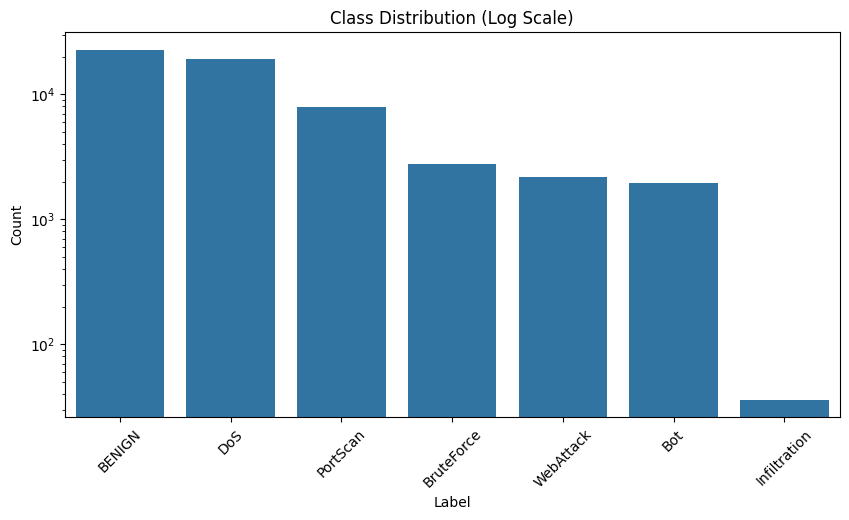

In [101]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=class_summary.reset_index(),
    x=target_column,
    y="Count"
)

plt.yscale("log")

plt.title("Class Distribution (Log Scale)")
plt.xticks(rotation=45)

plt.show()

# 3. Feature Engineering

In this section, we prepare the dataset for model training. Following the paper, we apply preprocessing steps including missing-value handling, Min-Max normalization, SMOTE for class imbalance, and feature selection based on tree-based feature importance.

In [102]:
# =========================
# 3.1 Prepare Features and Target
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42

# Remove constant features because they do not provide useful information for classification.
features_to_remove = constant_features.copy()

X = df.drop(columns=[target_column] + features_to_remove)
y = df[target_column]

print(f"Original feature count: {df.shape[1] - 1}")
print(f"Removed constant features: {len(features_to_remove)}")
print(f"Remaining feature count: {X.shape[1]}")

# Encode class labels into numeric values for machine learning models.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

print("Class mapping:")
print(class_mapping)

Original feature count: 77
Removed constant features: 8
Remaining feature count: 69
Class mapping:
{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'BruteForce': np.int64(2), 'DoS': np.int64(3), 'Infiltration': np.int64(4), 'PortScan': np.int64(5), 'WebAttack': np.int64(6)}


In [103]:
# =========================
# 3.2 Train/Test Split
# =========================

# Stratification preserves the class distribution in both training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (45328, 69)
Testing shape: (11333, 69)


In [104]:
# =========================
# 3.3 Missing Value Imputation
# =========================

# Median imputation is robust to skewed distributions and outliers.
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Missing values after imputation:")
print("Train:", X_train_imputed.isna().sum().sum())
print("Test:", X_test_imputed.isna().sum().sum())

Missing values after imputation:
Train: 0
Test: 0


In [105]:
# =========================
# 3.4 Min-Max Scaling
# =========================

# The paper applies Min-Max scaling to normalize features into a common range.
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

display(X_train_scaled.describe().T[["min", "max"]].head())

,min,max
Flow Duration,0.0,1.0
Total Fwd Packets,0.0,1.0
Total Backward Packets,0.0,1.0
Total Length of Fwd Packets,0.0,1.0
Total Length of Bwd Packets,0.0,1.0


In [106]:
# =========================
# 3.5 SMOTE for Class Imbalance
# =========================

!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

# SMOTE is applied only to the training set to avoid leaking synthetic information into the test set.
smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:", X_train_scaled.shape)
print("After SMOTE:", X_train_smote.shape)

smote_class_counts = pd.Series(y_train_smote).value_counts().sort_index()
smote_class_counts.index = label_encoder.inverse_transform(smote_class_counts.index)

display(smote_class_counts.to_frame("count_after_SMOTE"))

Before SMOTE: (45328, 69)
After SMOTE: (127288, 69)


,count_after_SMOTE
BENIGN,18184
Bot,18184
BruteForce,18184
DoS,18184
Infiltration,18184
PortScan,18184
WebAttack,18184


In [107]:
# =========================
# 3.6 Tree-Based Feature Selection
# =========================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False

# These models match the tree-based feature importance approach described in the paper.
feature_selectors = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

if xgboost_available:
    feature_selectors["XGBoost"] = XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=-1
    )

importance_df = pd.DataFrame(index=X_train_smote.columns)

for model_name, model in feature_selectors.items():
    print(f"Training {model_name} for feature importance...")
    model.fit(X_train_smote, y_train_smote)
    importance_df[model_name] = model.feature_importances_

# Average importance across all tree-based models.
importance_df["Average_Importance"] = importance_df.mean(axis=1)

importance_df = importance_df.sort_values(
    "Average_Importance",
    ascending=False
)

importance_df["Cumulative_Importance"] = (
    importance_df["Average_Importance"].cumsum()
    / importance_df["Average_Importance"].sum()
)

Training Decision Tree for feature importance...
Training Random Forest for feature importance...
Training Extra Trees for feature importance...
Training XGBoost for feature importance...


In [108]:
display(importance_df.head(69))

,Decision Tree,Random Forest,Extra Trees,XGBoost,Average_Importance,Cumulative_Importance
Init_Win_bytes_backward,0.237820,7.125258e-02,4.207859e-02,0.022942,9.352325e-02,0.093523
Bwd Packet Length Min,0.115396,4.215238e-02,4.315988e-02,0.092232,7.323507e-02,0.166758
PSH Flag Count,0.000219,1.240528e-02,5.456479e-02,0.151693,5.472058e-02,0.221479
Bwd Packet Length Std,0.080152,1.373289e-02,1.892189e-02,0.103977,5.419603e-02,0.275675
min_seg_size_forward,0.060025,2.630245e-02,4.947272e-02,0.041679,4.436972e-02,0.320045
Subflow Fwd Bytes,0.126208,3.568797e-02,6.249496e-03,0.000000,4.203638e-02,0.362081
Total Length of Fwd Packets,0.000000,2.980206e-02,7.586936e-03,0.119777,3.929144e-02,0.401372
Packet Length Mean,0.089178,2.838567e-02,1.819674e-02,0.014522,3.757057e-02,0.438943
Bwd Packets/s,0.065517,1.972115e-02,6.282191e-03,0.041354,3.321838e-02,0.472161
Init_Win_bytes_forward,0.014803,4.520136e-02,4.392682e-02,0.007280,2.780276e-02,0.499964


In [109]:
# =========================
# 3.7 Select Features up to 90% Cumulative Importance
# =========================

IMPORTANCE_THRESHOLD = 0.90

selected_features = importance_df[
    importance_df["Cumulative_Importance"] <= IMPORTANCE_THRESHOLD
].index.tolist()

# Add the first feature that crosses the 90% threshold.
next_feature = importance_df[
    importance_df["Cumulative_Importance"] > IMPORTANCE_THRESHOLD
].index[:1].tolist()

selected_features = selected_features + next_feature

print(f"Selected features: {len(selected_features)} out of {X_train_smote.shape[1]}")
print(selected_features)

X_train_selected = X_train_smote[selected_features]
X_test_selected = X_test_scaled[selected_features]

print("Selected train shape:", X_train_selected.shape)
print("Selected test shape:", X_test_selected.shape)

Selected features: 44 out of 69
['Init_Win_bytes_backward', 'Bwd Packet Length Min', 'PSH Flag Count', 'Bwd Packet Length Std', 'min_seg_size_forward', 'Subflow Fwd Bytes', 'Total Length of Fwd Packets', 'Packet Length Mean', 'Bwd Packets/s', 'Init_Win_bytes_forward', 'Bwd Packet Length Mean', 'Subflow Bwd Bytes', 'Average Packet Size', 'Total Fwd Packets', 'Bwd Packet Length Max', 'Flow IAT Max', 'Fwd Header Length', 'Fwd Packet Length Std', 'Avg Bwd Segment Size', 'Packet Length Std', 'Bwd IAT Min', 'URG Flag Count', 'Flow IAT Std', 'Fwd Packet Length Mean', 'Flow Duration', 'Min Packet Length', 'Max Packet Length', 'Fwd IAT Max', 'Flow Bytes/s', 'ACK Flag Count', 'Fwd Packet Length Max', 'Bwd IAT Total', 'Fwd IAT Std', 'Avg Fwd Segment Size', 'Flow IAT Mean', 'Total Length of Bwd Packets', 'Fwd Packet Length Min', 'Bwd Header Length', 'Fwd IAT Total', 'act_data_pkt_fwd', 'Down/Up Ratio', 'Packet Length Variance', 'Total Backward Packets', 'Fwd IAT Min']
Selected train shape: (127288

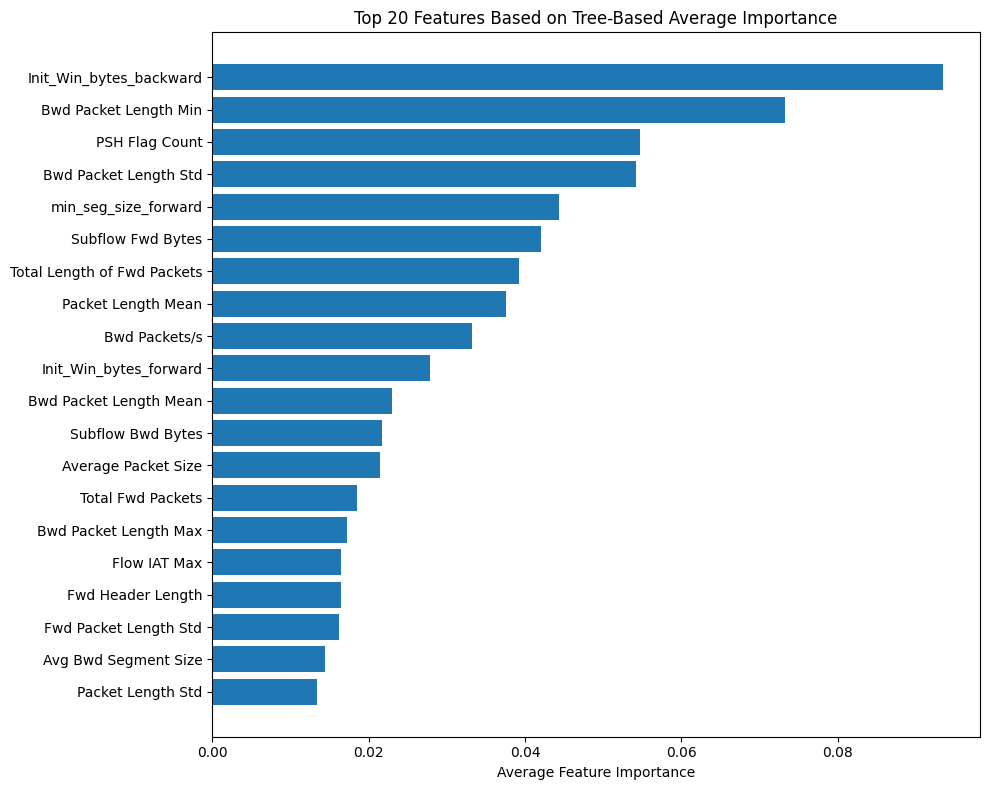

In [110]:
# =========================
# 3.8 Feature Importance Plot
# =========================

top_features = importance_df.head(20).sort_values("Average_Importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features.index, top_features["Average_Importance"])
plt.xlabel("Average Feature Importance")
plt.title("Top 20 Features Based on Tree-Based Average Importance")
plt.tight_layout()
plt.show()

## Notes on Feature Creation and Dimensionality Reduction

No additional features were created in this reproduction because the CICIDS2017 dataset already contains engineered network-flow features.

Dimensionality reduction methods such as PCA were not applied because the original paper uses feature selection rather than feature extraction. Feature selection keeps the original feature meanings, which is important for cybersecurity interpretation.

# 4. Model Training & Evaluation
In this section, we train the main tree-based models proposed in the original paper: Decision Tree, Random Forest, Extra Trees, XGBoost, and a Stacking ensemble. The 44 features selected during the feature engineering stage are used for training. The trained models are then evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, and execution time, and their results are compared with those reported in the original paper.

In [125]:
# =========================
# 4.1 Imports for Training
# =========================

import time
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [126]:
# =========================
# 4.2 Evaluation Function
# =========================

def train_and_evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    """
    Train a classification model and return its performance metrics.
    Training and prediction time are also measured.
    """

    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    # Macro averaging treats all classes equally, which is important for imbalanced IDS data.
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall_Macro": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1_Macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),

        # Matthews Correlation Coefficient
        "MCC": matthews_corrcoef(
            y_test,
            y_pred
        ),

        "Train_Time_Seconds": train_time,
        "Test_Time_Seconds": test_time
    }

    return results, y_pred, model

In [127]:
# =========================
# 4.3 Define Models
# =========================

# Hyperparameters are kept close to the paper where possible:
# number of trees = 200, max depth = 8, min samples split = 8, min samples leaf = 3.

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=-1
    )
}

In [128]:
# =========================
# 4.4 Train Base Models
# =========================

model_results = []
model_predictions = {}
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    results, predictions, trained_model = train_and_evaluate_model(
        model=model,
        model_name=model_name,
        X_train=X_train_selected,
        y_train=y_train_smote,
        X_test=X_test_selected,
        y_test=y_test
    )

    model_results.append(results)
    model_predictions[model_name] = predictions
    trained_models[model_name] = trained_model

    print(f"{model_name} completed.")

Training Decision Tree...
Decision Tree completed.
Training Random Forest...
Random Forest completed.
Training Extra Trees...
Extra Trees completed.
Training XGBoost...
XGBoost completed.


In [129]:
# =========================
# 4.5 Base Model Results
# =========================

base_results_df = pd.DataFrame(model_results)

display(
    base_results_df.sort_values(
        "F1_Macro",
        ascending=False
    )
)

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,MCC,Train_Time_Seconds,Test_Time_Seconds
3,XGBoost,0.996470,0.973421,0.976012,0.974705,0.994971,20.907905,0.167959
1,Random Forest,0.958087,0.921059,0.954909,0.931792,0.942131,30.528836,0.100738
0,Decision Tree,0.941322,0.860362,0.943934,0.895433,0.918117,2.129755,0.002904
2,Extra Trees,0.851231,0.713161,0.908999,0.757539,0.811405,4.533907,0.096785


In [130]:
# =========================
# 4.6 Select Meta-Classifier for Stacking
# =========================

# Following the paper, the best individual model is selected as the meta-classifier.
best_base_model_name = (
    base_results_df
    .sort_values("F1_Macro", ascending=False)
    .iloc[0]["Model"]
)

best_meta_classifier = trained_models[best_base_model_name]

print(f"Best base model selected as meta-classifier: {best_base_model_name}")

Best base model selected as meta-classifier: XGBoost


In [131]:
# =========================
# 4.7 Train Stacking Ensemble
# =========================

# The paper uses tree-based models as base learners in a stacking ensemble.
base_estimators = [
    ("dt", models["Decision Tree"]),
    ("rf", models["Random Forest"]),
    ("et", models["Extra Trees"]),
    ("xgb", models["XGBoost"])
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=best_meta_classifier,
    cv=5,
    n_jobs=-1
)

stacking_results, stacking_predictions, trained_stacking_model = train_and_evaluate_model(
    model=stacking_model,
    model_name="Stacking",
    X_train=X_train_selected,
    y_train=y_train_smote,
    X_test=X_test_selected,
    y_test=y_test
)

model_results.append(stacking_results)
model_predictions["Stacking"] = stacking_predictions
trained_models["Stacking"] = trained_stacking_model

print("Stacking model completed.")

Stacking model completed.


In [132]:
# =========================
# 4.8 Final Model Comparison
# =========================

results_df = pd.DataFrame(model_results)

results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision_Macro",
    "Recall_Macro",
    "F1_Macro",
    "MCC"
]

# Convert performance metrics to percentages.
results_display[metric_columns] = (
    results_display[metric_columns] * 100
).round(2)

# Round timing values.
results_display["Train_Time_Seconds"] = results_display["Train_Time_Seconds"].round(2)
results_display["Test_Time_Seconds"] = results_display["Test_Time_Seconds"].round(4)

# Add total execution time for comparison with the paper.
results_display["Total_Execution_Time_Seconds"] = (
    results_display["Train_Time_Seconds"]
    + results_display["Test_Time_Seconds"]
).round(2)

# Rename columns for presentation.
results_display = results_display.rename(columns={
    "Accuracy": "Accuracy (%)",
    "Precision_Macro": "Precision (%)",
    "Recall_Macro": "Recall (%)",
    "F1_Macro": "F1-score (%)",
    "Train_Time_Seconds": "Training Time (s)",
    "Test_Time_Seconds": "Prediction Time (s)",
    "Total_Execution_Time_Seconds": "Total Execution Time (s)"
})

final_results_table = (
    results_display
    .sort_values("F1-score (%)", ascending=False)
    .reset_index(drop=True)
)

display(final_results_table)

,Model,Accuracy (%),Precision (%),Recall (%),F1-score (%),MCC,Training Time (s),Prediction Time (s),Total Execution Time (s)
0,Stacking,99.68,99.55,97.62,98.50,99.55,304.42,0.5073,304.93
1,XGBoost,99.65,97.34,97.60,97.47,99.50,20.91,0.1680,21.08
2,Random Forest,95.81,92.11,95.49,93.18,94.21,30.53,0.1007,30.63
3,Decision Tree,94.13,86.04,94.39,89.54,91.81,2.13,0.0029,2.13
4,Extra Trees,85.12,71.32,90.90,75.75,81.14,4.53,0.0968,4.63


In [133]:
# =========================
# 4.9 Classification Report for Best Model
# =========================

best_model_name = (
    results_df
    .sort_values("F1_Macro", ascending=False)
    .iloc[0]["Model"]
)

best_predictions = model_predictions[best_model_name]

print(f"Best model based on macro F1-score: {best_model_name}")

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Best model based on macro F1-score: Stacking
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      4547
         Bot       0.98      0.99      0.99       393
  BruteForce       1.00      1.00      1.00       554
         DoS       1.00      1.00      1.00      3807
Infiltration       1.00      0.86      0.92         7
    PortScan       1.00      1.00      1.00      1589
   WebAttack       0.99      0.99      0.99       436

    accuracy                           1.00     11333
   macro avg       1.00      0.98      0.99     11333
weighted avg       1.00      1.00      1.00     11333



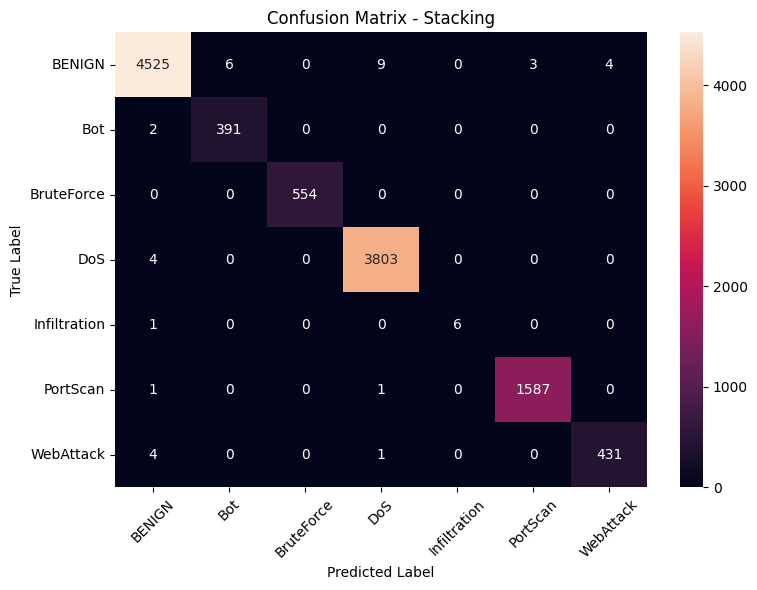

In [134]:
# =========================
# 4.10 Confusion Matrix for Best Model
# =========================

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [135]:
# =========================
# 4.11 Comparison with the Original Paper
# =========================

# Reported CICIDS2017 results from the original paper.
paper_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "Stacking"
    ],
    "Paper Accuracy (%)": [
        99.72,
        98.37,
        93.43,
        99.78,
        99.86
    ],
    "Paper F1-score (%)": [
        99.80,
        98.30,
        93.40,
        99.70,
        99.80
    ],
    "Paper Execution Time (s)": [
        126.7,
        2421.6,
        2349.6,
        1637.2,
        4519.3
    ]
})

our_results = final_results_table[
    [
        "Model",
        "Accuracy (%)",
        "F1-score (%)",
        "Total Execution Time (s)"
    ]
]

comparison_df = paper_results.merge(
    our_results,
    on="Model",
    how="left"
)

comparison_df["Accuracy Difference"] = (
    comparison_df["Accuracy (%)"]
    - comparison_df["Paper Accuracy (%)"]
).round(2)

comparison_df["F1 Difference"] = (
    comparison_df["F1-score (%)"]
    - comparison_df["Paper F1-score (%)"]
).round(2)

comparison_df["Execution Time Difference (s)"] = (
    comparison_df["Total Execution Time (s)"]
    - comparison_df["Paper Execution Time (s)"]
).round(2)

display(comparison_df)

,Model,Paper Accuracy (%),Paper F1-score (%),Paper Execution Time (s),Accuracy (%),F1-score (%),Total Execution Time (s),Accuracy Difference,F1 Difference,Execution Time Difference (s)
0,Decision Tree,99.72,99.8,126.7,94.13,89.54,2.13,-5.59,-10.26,-124.57
1,Random Forest,98.37,98.3,2421.6,95.81,93.18,30.63,-2.56,-5.12,-2390.97
2,Extra Trees,93.43,93.4,2349.6,85.12,75.75,4.63,-8.31,-17.65,-2344.97
3,XGBoost,99.78,99.7,1637.2,99.65,97.47,21.08,-0.13,-2.23,-1616.12
4,Stacking,99.86,99.8,4519.3,99.68,98.50,304.93,-0.18,-1.30,-4214.37
